# 13A — Final 3-Seed Replication: Disease + Finding Multitask — Seeds 123 & 2026

**Project:** Pediatric Chest X-ray / final robustness stage  
**Controller ID:** `F01_Multitask_3Seed_Replication`  
**Frozen reference run:** `M01_DiseaseFinding_Multitask_Seed42`  
**New runs:** seeds **123** and **2026**  
**Platform:** Kaggle  
**Target GPU:** NVIDIA T4  

## Why this comes before the official test

The development choices are now effectively frozen, but the final paper-quality methodology still needs repeated-seed evidence before opening the sealed test set.

The disease-only Focal model already has three-seed results.  
The final medical-supervision classifier used by the localization/calibration pipeline currently has only the seed-42 09A run.

So 13A repeats **the exact 09A protocol** for seeds:

- 123
- 2026

and combines them with the existing seed-42 run to produce a clean **3-seed multitask summary**.

## Controlled protocol

The only intended scientific change is the random seed.

Frozen across all three runs:

- ResNet50
- 320 × 320
- ImageNet initialization
- Binary Focal Loss, `gamma = 2`
- disease outputs = 15
- finding outputs = 37
- finding loss weight = `0.5`
- AdamW, LR `1e-4`, weight decay `1e-4`
- max epochs = 25
- early stopping patience = 5
- checkpoint selection = validation **14-pathology Macro-AUPRC**
- same Stage-02 split
- no boxes
- no calibration
- no official test

The historical preprocessing normalization is intentionally preserved exactly for controlled replication.

## What this notebook exports

For seeds 123 and 2026:

- best checkpoints;
- training histories;
- validation predictions;
- disease metrics;
- finding metrics;
- Head/Middle/Tail metrics.

Then it creates:

- a 3-seed summary using **42, 123, 2026**;
- mean ± SD for the major metrics;
- per-class 3-seed AUPRC summary;
- one complete ZIP.

After 13A, the next robustness step is the corresponding **10E localization-adapter replication** for seeds 123 and 2026.


In [1]:
# ============================================================
# 1. Install DICOM decoders
# ============================================================
%pip install -q -U "pylibjpeg[all]" pyjpegls

print("✅ DICOM decoder packages ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.3/272.3 kB 18.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
✅ DICOM decoder packages ready.


In [2]:
# ============================================================
# 2. Imports + frozen controller configuration
# ============================================================
import os
import sys
import gc
import io
import json
import time
import math
import random
import hashlib
import zipfile
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pydicom
from pydicom.pixels import apply_modality_lut, apply_voi_lut
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    recall_score,
    confusion_matrix,
)

from tqdm.auto import tqdm

CONTROLLER_ID = "F01_Multitask_3Seed_Replication"

REFERENCE_EXPERIMENT_ID = (
    "M01_DiseaseFinding_Multitask_Seed42"
)

NEW_SEEDS = [
    123,
    2026,
]

RUN_EXPERIMENT_IDS = {
    123:
        "F01_Multitask_Seed123",
    2026:
        "F01_Multitask_Seed2026",
}

IMAGE_SIZE = 320
BATCH_SIZE = 8
NUM_WORKERS = 4
MAX_EPOCHS = 25
EARLY_STOPPING_PATIENCE = 5
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
FIXED_THRESHOLD = 0.5
USE_AMP = True

FOCAL_GAMMA = 2.0
FINDING_LOSS_WEIGHT = 0.5

EXPECTED_SPLIT_MANIFEST_SHA256 = (
    "3d2f8de854c9f61382b1ef5594264af739fcb1d3d9ca8ca9fe8d388380363770"
)

OUTPUT_ROOT = Path(
    f"/kaggle/working/PediCGAM/{CONTROLLER_ID}"
)

CACHE_ROOT = Path(
    f"/kaggle/working/PediCGAM_cache/{CONTROLLER_ID}_{IMAGE_SIZE}"
)

SUMMARY_DIR = (
    OUTPUT_ROOT
    / "summary"
)

for d in [
    OUTPUT_ROOT,
    CACHE_ROOT,
    SUMMARY_DIR,
]:
    d.mkdir(
        parents=True,
        exist_ok=True,
    )

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

if (
    DEVICE.type
    != "cuda"
):
    raise RuntimeError(
        "GPU is not active. Enable a Kaggle GPU accelerator."
    )

print(
    "Notebook build:",
    "13A_MULTITASK_FINAL_REPLICATION_V1",
)
print(
    "Controller:",
    CONTROLLER_ID,
)
print(
    "New seeds:",
    NEW_SEEDS,
)
print(
    "Device:",
    DEVICE,
)
print(
    "GPU:",
    torch.cuda.get_device_name(
        0
    ),
)


Notebook build: 13A_MULTITASK_FINAL_REPLICATION_V1
Controller: F01_Multitask_3Seed_Replication
New seeds: [123, 2026]
Device: cuda
GPU: Tesla T4


# 3. Required Kaggle inputs

Attach **three inputs**:

1. **VinDr-PCXR**
2. **Stage-02 frozen split output**
3. **Executed 09A / M01 seed-42 output** containing:
   - `best_model.pth`
   - `per_class_metrics.csv`
   - `head_middle_tail_metrics.csv`
   - `finding_summary_metrics.csv`

Internet should be **ON** so the notebook can obtain the same ImageNet ResNet50 initialization used by 09A.

Calibration and official test remain unused.


In [3]:
# ============================================================
# 4. Reproducibility helper
# ============================================================
def seed_everything(
    seed,
):
    random.seed(
        seed
    )
    np.random.seed(
        seed
    )
    torch.manual_seed(
        seed
    )
    torch.cuda.manual_seed_all(
        seed
    )

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [4]:
# ============================================================
# 5. Locate VinDr-PCXR
# ============================================================
KAGGLE_INPUT = Path(
    "/kaggle/input"
)


def find_vindr_root(
    search_root=KAGGLE_INPUT,
):
    candidates = []

    for f in search_root.rglob(
        "image_labels_train.csv"
    ):
        folder = f.parent

        names = {
            p.name
            for p in folder.iterdir()
            if p.is_file()
        }

        score = sum(
            x in names
            for x in [
                "image_labels_train.csv",
                "annotations_train.csv",
            ]
        )

        candidates.append(
            (
                score,
                folder,
            )
        )

    candidates.sort(
        key=lambda x: (
            -x[
                0
            ],
            len(
                str(
                    x[
                        1
                    ]
                )
            ),
        )
    )

    return candidates


vindr_candidates = (
    find_vindr_root()
)

if (
    not vindr_candidates
):
    raise FileNotFoundError(
        "VinDr-PCXR was not found."
    )

DATA_ROOT = (
    vindr_candidates[
        0
    ][
        1
    ]
)

TRAIN_DICOM_DIR = (
    DATA_ROOT
    / "train"
)

if (
    not TRAIN_DICOM_DIR.exists()
):
    raise FileNotFoundError(
        "VinDr-PCXR train DICOM directory was not found."
    )

print(
    "VinDr-PCXR root:",
    DATA_ROOT,
)


VinDr-PCXR root: /kaggle/input/datasets/kalloldaskushol/vindr-pcxr/Pediatric Chest X-ray/physionet.org/files/vindr-pcxr/1.0.0


In [5]:
# ============================================================
# 6. Locate + verify frozen Stage-02 manifest
# ============================================================
def sha256_file(
    path,
):
    h = hashlib.sha256()

    with open(
        path,
        "rb",
    ) as f:
        for block in iter(
            lambda:
                f.read(
                    1024
                    * 1024
                ),
            b"",
        ):
            h.update(
                block
            )

    return h.hexdigest()


def find_frozen_manifest():
    for p in KAGGLE_INPUT.rglob(
        "fixed_split_manifest.csv"
    ):
        if (
            sha256_file(
                p
            )
            == EXPECTED_SPLIT_MANIFEST_SHA256
        ):
            return (
                p,
                "direct_csv",
            )

    for zip_path in KAGGLE_INPUT.rglob(
        "*.zip"
    ):
        try:
            with zipfile.ZipFile(
                zip_path,
                "r",
            ) as zf:
                members = [
                    n
                    for n in zf.namelist()
                    if n.endswith(
                        "fixed_split_manifest.csv"
                    )
                ]

                for member in members:
                    raw = zf.read(
                        member
                    )

                    if (
                        hashlib.sha256(
                            raw
                        ).hexdigest()
                        == EXPECTED_SPLIT_MANIFEST_SHA256
                    ):
                        target = Path(
                            "/kaggle/working/"
                            "stage02_manifest_13a.csv"
                        )

                        target.write_bytes(
                            raw
                        )

                        return (
                            target,
                            f"zip:{zip_path.name}",
                        )

        except zipfile.BadZipFile:
            pass

    return (
        None,
        None,
    )


MANIFEST_PATH, MANIFEST_SOURCE = (
    find_frozen_manifest()
)

if (
    MANIFEST_PATH
    is None
):
    raise FileNotFoundError(
        "Frozen Stage-02 split was not found."
    )

manifest_hash = sha256_file(
    MANIFEST_PATH
)

if (
    manifest_hash
    != EXPECTED_SPLIT_MANIFEST_SHA256
):
    raise RuntimeError(
        "STOP: Stage-02 split hash mismatch."
    )

print(
    "Manifest:",
    MANIFEST_PATH,
)
print(
    "Source:",
    MANIFEST_SOURCE,
)
print(
    "SHA-256:",
    manifest_hash,
)
print(
    "✅ Frozen split verified."
)


Manifest: /kaggle/input/notebooks/kalloldaskushol/02-fixed-train-validation-calibration-split/PediCGAM/stage02_fixed_split/splits/fixed_split_manifest.csv
Source: direct_csv
SHA-256: 3d2f8de854c9f61382b1ef5594264af739fcb1d3d9ca8ca9fe8d388380363770
✅ Frozen split verified.


In [6]:
# ============================================================
# 7. Locate + verify seed-42 09A reference artifacts
# ============================================================
REFERENCE_EXTRACT_DIR = Path(
    "/kaggle/working/13a_reference09a"
)

REFERENCE_EXTRACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def locate_reference_file(
    filename,
):
    direct = list(
        KAGGLE_INPUT.rglob(
            filename
        )
    )

    for p in direct:
        # best_model.pth requires ID verification below;
        # CSV files are accepted after checkpoint is verified.
        if (
            filename
            != "best_model.pth"
        ):
            return (
                p,
                "direct",
            )

    for zip_path in KAGGLE_INPUT.rglob(
        "*.zip"
    ):
        try:
            with zipfile.ZipFile(
                zip_path,
                "r",
            ) as zf:
                members = [
                    n
                    for n in zf.namelist()
                    if n.endswith(
                        "/"
                        + filename
                    )
                    or n
                    == filename
                ]

                for member in members:
                    raw = zf.read(
                        member
                    )

                    target = (
                        REFERENCE_EXTRACT_DIR
                        / filename
                    )

                    target.write_bytes(
                        raw
                    )

                    if (
                        filename
                        != "best_model.pth"
                    ):
                        return (
                            target,
                            f"zip:{zip_path.name}",
                        )

                    try:
                        candidate = torch.load(
                            target,
                            map_location="cpu",
                            weights_only=False,
                        )

                        if (
                            candidate.get(
                                "experiment_id"
                            )
                            == REFERENCE_EXPERIMENT_ID
                            and candidate.get(
                                "split_manifest_sha256"
                            )
                            == EXPECTED_SPLIT_MANIFEST_SHA256
                            and np.isclose(
                                float(
                                    candidate.get(
                                        "finding_loss_weight"
                                    )
                                ),
                                FINDING_LOSS_WEIGHT,
                            )
                            and candidate.get(
                                "boxes_used"
                            )
                            is False
                        ):
                            return (
                                target,
                                f"zip:{zip_path.name}",
                            )

                    except Exception:
                        pass

        except zipfile.BadZipFile:
            pass

    if (
        filename
        == "best_model.pth"
    ):
        for p in direct:
            try:
                candidate = torch.load(
                    p,
                    map_location="cpu",
                    weights_only=False,
                )

                if (
                    candidate.get(
                        "experiment_id"
                    )
                    == REFERENCE_EXPERIMENT_ID
                    and candidate.get(
                        "split_manifest_sha256"
                    )
                    == EXPECTED_SPLIT_MANIFEST_SHA256
                    and np.isclose(
                        float(
                            candidate.get(
                                "finding_loss_weight"
                            )
                        ),
                        FINDING_LOSS_WEIGHT,
                    )
                    and candidate.get(
                        "boxes_used"
                    )
                    is False
                ):
                    return (
                        p,
                        "direct",
                    )

            except Exception:
                pass

    return (
        None,
        None,
    )


REFERENCE_CHECKPOINT_PATH, REFERENCE_CHECKPOINT_SOURCE = (
    locate_reference_file(
        "best_model.pth"
    )
)

if (
    REFERENCE_CHECKPOINT_PATH
    is None
):
    raise FileNotFoundError(
        "Verified seed-42 09A best_model.pth was not found."
    )

reference_checkpoint = torch.load(
    REFERENCE_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

print(
    "✅ Seed-42 09A checkpoint verified"
)
print(
    "Stored AP14:",
    reference_checkpoint.get(
        "selection_metric_value"
    ),
)


✅ Seed-42 09A checkpoint verified
Stored AP14: 0.20847144131991252


In [7]:
# ============================================================
# 8. Load labels + frozen split
# ============================================================
labels = pd.read_csv(
    DATA_ROOT
    / "image_labels_train.csv"
)

manifest = pd.read_csv(
    MANIFEST_PATH
)

NON_LABEL_COLUMNS = [
    "image_id",
    "rad_ID",
]

LABEL_COLUMNS = [
    c
    for c in labels.columns
    if c
    not in NON_LABEL_COLUMNS
]

if (
    len(
        LABEL_COLUMNS
    )
    != 15
):
    raise RuntimeError(
        "Expected 15 disease outputs."
    )

if (
    "No finding"
    not in LABEL_COLUMNS
):
    raise RuntimeError(
        "Disease label 'No finding' is missing."
    )

PATHOLOGY_COLUMNS = [
    c
    for c in LABEL_COLUMNS
    if c
    != "No finding"
]

df = manifest.merge(
    labels,
    on="image_id",
    how="left",
    validate="one_to_one",
)

if (
    df[
        LABEL_COLUMNS
    ].isna()
    .any()
    .any()
):
    raise RuntimeError(
        "Manifest-label merge has missing disease labels."
    )

split_counts = (
    df[
        "split"
    ].value_counts()
)

if (
    int(
        split_counts[
            "train"
        ]
    )
    != 5408
    or int(
        split_counts[
            "validation"
        ]
    )
    != 1159
    or int(
        split_counts[
            "calibration"
        ]
    )
    != 1161
):
    raise RuntimeError(
        "Frozen split counts are incorrect."
    )

train_df = (
    df[
        df[
            "split"
        ]
        == "train"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

val_df = (
    df[
        df[
            "split"
        ]
        == "validation"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

print(
    "Train:",
    len(
        train_df
    ),
)
print(
    "Validation:",
    len(
        val_df
    ),
)
print(
    "Calibration present but unused:",
    int(
        split_counts[
            "calibration"
        ]
    ),
)


Train: 5408
Validation: 1159
Calibration present but unused: 1161


In [8]:
# ============================================================
# 9. Build 37 finding targets using annotation class_name
# ============================================================
annotations = pd.read_csv(
    DATA_ROOT
    / "annotations_train.csv"
)

required_annotation_columns = {
    "image_id",
    "class_name",
}

if (
    not required_annotation_columns.issubset(
        annotations.columns
    )
):
    raise RuntimeError(
        "annotations_train.csv is missing required columns."
    )

annotation_class_names = (
    annotations[
        "class_name"
    ]
    .dropna()
    .astype(
        str
    )
    .unique()
    .tolist()
)

FINDING_CLASSES = (
    [
        "No finding"
    ]
    + sorted(
        x
        for x in annotation_class_names
        if x
        != "No finding"
    )
)

if (
    len(
        FINDING_CLASSES
    )
    != 37
):
    raise RuntimeError(
        "Expected 37 finding outputs."
    )

FINDING_TARGET_COLUMNS = [
    f"finding_target_{i:02d}"
    for i in range(
        len(
            FINDING_CLASSES
        )
    )
]

finding_matrix = pd.crosstab(
    annotations[
        "image_id"
    ].astype(
        str
    ),
    annotations[
        "class_name"
    ].astype(
        str
    ),
)

finding_matrix = (
    finding_matrix
    .reindex(
        columns=
            FINDING_CLASSES,
        fill_value=0,
    )
    .clip(
        upper=1
    )
    .astype(
        np.float32
    )
)

df[
    "image_id_str"
] = (
    df[
        "image_id"
    ].astype(
        str
    )
)

for target_col, class_name in zip(
    FINDING_TARGET_COLUMNS,
    FINDING_CLASSES,
):
    df[
        target_col
    ] = (
        df[
            "image_id_str"
        ]
        .map(
            finding_matrix[
                class_name
            ]
        )
        .fillna(
            0
        )
        .astype(
            np.float32
        )
    )

finding_row_sums = (
    df[
        FINDING_TARGET_COLUMNS
    ].sum(
        axis=1
    )
)

if (
    finding_row_sums
    <= 0
).any():
    raise RuntimeError(
        "At least one frozen-split image has no finding target."
    )

no_finding_col = (
    FINDING_TARGET_COLUMNS[
        FINDING_CLASSES.index(
            "No finding"
        )
    ]
)

other_finding_cols = [
    c
    for c, name in zip(
        FINDING_TARGET_COLUMNS,
        FINDING_CLASSES,
    )
    if name
    != "No finding"
]

if (
    (
        df[
            no_finding_col
        ]
        == 1
    )
    & (
        df[
            other_finding_cols
        ].sum(
            axis=1
        )
        > 0
    )
).any():
    raise RuntimeError(
        "Contradictory No finding + abnormal finding targets detected."
    )

train_df = (
    df[
        df[
            "split"
        ]
        == "train"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

val_df = (
    df[
        df[
            "split"
        ]
        == "validation"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

print(
    "Finding outputs:",
    len(
        FINDING_CLASSES
    ),
)
print(
    "Numeric class_id used:",
    "NO",
)


Finding outputs: 37
Numeric class_id used: NO


In [9]:
# ============================================================
# 10. Load frozen Head / Middle / Tail groups
# ============================================================
def load_stage02_csv(
    filename,
):
    matches = list(
        KAGGLE_INPUT.rglob(
            filename
        )
    )

    if matches:
        return pd.read_csv(
            matches[
                0
            ]
        )

    for zip_path in KAGGLE_INPUT.rglob(
        "*.zip"
    ):
        try:
            with zipfile.ZipFile(
                zip_path,
                "r",
            ) as zf:
                members = [
                    n
                    for n in zf.namelist()
                    if n.endswith(
                        filename
                    )
                ]

                if members:
                    return pd.read_csv(
                        io.BytesIO(
                            zf.read(
                                members[
                                    0
                                ]
                            )
                        )
                    )

        except zipfile.BadZipFile:
            pass

    return None


rarity_groups = (
    load_stage02_csv(
        "frozen_pathology_head_middle_tail_groups.csv"
    )
)

if (
    rarity_groups
    is None
):
    raise FileNotFoundError(
        "Frozen pathology rarity groups were not found."
    )

rarity_groups = (
    rarity_groups[
        [
            "label",
            "positive_images",
            "frequency_rank",
            "rarity_group",
        ]
    ]
    .copy()
)

if (
    set(
        rarity_groups[
            "label"
        ]
    )
    != set(
        PATHOLOGY_COLUMNS
    )
):
    raise RuntimeError(
        "Rarity groups do not match pathology labels."
    )

GROUP_TO_LABELS = {
    group:
        rarity_groups.loc[
            rarity_groups[
                "rarity_group"
            ]
            == group,
            "label",
        ].tolist()
    for group in [
        "Head",
        "Middle",
        "Tail",
    ]
}

display(
    rarity_groups
)


,label,positive_images,frequency_rank,rarity_group
0,Bronchitis,842,1,Head
1,Brocho-pneumonia,545,2,Head
2,Bronchiolitis,497,3,Head
3,Other disease,412,4,Head
4,Pneumonia,392,5,Head
5,Hyaline membrane disease,19,6,Middle
6,Tuberculosis,14,7,Middle
7,Situs inversus,11,8,Middle
8,Mediastinal tumor,8,9,Middle
9,Pleuro-pneumonia,6,10,Middle


In [10]:
# ============================================================
# 11. DICOM map + shared cache
# ============================================================
dicom_paths = {
    p.stem:
        p
    for p in TRAIN_DICOM_DIR.rglob(
        "*"
    )
    if (
        p.is_file()
        and p.suffix.lower()
        in {
            ".dicom",
            ".dcm",
        }
    )
}

required_ids = (
    set(
        train_df[
            "image_id"
        ].astype(
            str
        )
    )
    | set(
        val_df[
            "image_id"
        ].astype(
            str
        )
    )
)

missing = (
    required_ids
    - set(
        dicom_paths.keys()
    )
)

if (
    missing
):
    raise FileNotFoundError(
        "Some train/validation DICOM files are missing."
    )


def dicom_to_uint8_320(
    path,
    output_size=IMAGE_SIZE,
):
    ds = pydicom.dcmread(
        str(
            path
        )
    )

    arr = ds.pixel_array

    try:
        arr = apply_modality_lut(
            arr,
            ds,
        )
    except Exception:
        arr = np.asarray(
            arr
        )

    try:
        arr = apply_voi_lut(
            arr,
            ds,
        )
    except Exception:
        arr = np.asarray(
            arr
        )

    arr = np.asarray(
        arr,
        dtype=np.float32,
    )

    if (
        not np.isfinite(
            arr
        ).all()
    ):
        finite = arr[
            np.isfinite(
                arr
            )
        ]

        fill = (
            float(
                np.median(
                    finite
                )
            )
            if finite.size
            else 0.0
        )

        arr = np.nan_to_num(
            arr,
            nan=fill,
            posinf=fill,
            neginf=fill,
        )

    if (
        str(
            getattr(
                ds,
                "PhotometricInterpretation",
                "",
            )
        ).upper()
        == "MONOCHROME1"
    ):
        arr = (
            arr.max()
            + arr.min()
            - arr
        )

    lo, hi = np.percentile(
        arr,
        [
            0.5,
            99.5,
        ],
    )

    if (
        not np.isfinite(
            lo
        )
        or not np.isfinite(
            hi
        )
        or hi
        <= lo
    ):
        lo = float(
            arr.min()
        )
        hi = float(
            arr.max()
        )

    if (
        hi
        > lo
    ):
        arr = np.clip(
            arr,
            lo,
            hi,
        )

        arr = (
            arr
            - lo
        ) / (
            hi
            - lo
        )

    else:
        arr = np.zeros_like(
            arr,
            dtype=np.float32,
        )

    arr = (
        arr
        * 255.0
    ).round().astype(
        np.uint8
    )

    image = Image.fromarray(
        arr
    )

    image = image.resize(
        (
            output_size,
            output_size,
        ),
        resample=
            Image.Resampling.BILINEAR,
    )

    return np.asarray(
        image,
        dtype=np.uint8,
    )


def cache_images(
    dataframe,
    split_name,
):
    cache_dir = (
        CACHE_ROOT
        / split_name
    )

    cache_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    failures = []

    for image_id in tqdm(
        dataframe[
            "image_id"
        ].astype(
            str
        ).tolist(),
        desc=
            f"Caching {split_name}",
    ):
        target = (
            cache_dir
            / f"{image_id}.npy"
        )

        if (
            target.exists()
        ):
            continue

        try:
            arr = dicom_to_uint8_320(
                dicom_paths[
                    image_id
                ]
            )

            np.save(
                target,
                arr,
                allow_pickle=False,
            )

        except Exception as e:
            failures.append({
                "split":
                    split_name,
                "image_id":
                    image_id,
                "error":
                    (
                        f"{type(e).__name__}: "
                        f"{e}"
                    ),
            })

    return pd.DataFrame(
        failures
    )


cache_failures = pd.concat(
    [
        cache_images(
            train_df,
            "train",
        ),
        cache_images(
            val_df,
            "validation",
        ),
    ],
    ignore_index=True,
)

if (
    len(
        cache_failures
    )
):
    display(
        cache_failures
    )

    raise RuntimeError(
        "Preprocessing failure detected."
    )

print(
    "✅ Shared 320×320 cache complete."
)


Caching train:   0%|          | 0/5408 [00:00<?, ?it/s]

Caching validation:   0%|          | 0/1159 [00:00<?, ?it/s]

✅ Shared 320×320 cache complete.


In [11]:
# ============================================================
# 12. Exact 09A transforms + dataset
# ============================================================
IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406,
]

# Intentionally preserved from the executed Stage-09 protocol.
IMAGENET_STD = [
    0.229,
    0.320,
    0.225,
]

train_transform = (
    transforms.Compose(
        [
            transforms.RandomAffine(
                degrees=5,
                translate=(
                    0.03,
                    0.03,
                ),
                scale=(
                    0.95,
                    1.05,
                ),
                fill=0,
            ),
            transforms.ColorJitter(
                brightness=0.10,
                contrast=0.10,
            ),
            transforms.Normalize(
                mean=
                    IMAGENET_MEAN,
                std=
                    IMAGENET_STD,
            ),
        ]
    )
)

val_transform = (
    transforms.Compose(
        [
            transforms.Normalize(
                mean=
                    IMAGENET_MEAN,
                std=
                    IMAGENET_STD,
            ),
        ]
    )
)


class CachedCXRDataset(
    Dataset
):
    def __init__(
        self,
        dataframe,
        split_name,
        transform,
    ):
        self.df = (
            dataframe
            .reset_index(
                drop=True
            )
        )

        self.cache_dir = (
            CACHE_ROOT
            / split_name
        )

        self.transform = (
            transform
        )

    def __len__(
        self,
    ):
        return len(
            self.df
        )

    def __getitem__(
        self,
        idx,
    ):
        row = (
            self.df.iloc[
                idx
            ]
        )

        image_id = str(
            row[
                "image_id"
            ]
        )

        arr = np.load(
            self.cache_dir
            / f"{image_id}.npy",
            allow_pickle=False,
        )

        x = (
            torch.from_numpy(
                arr
            )
            .float()
            .unsqueeze(
                0
            )
            / 255.0
        )

        x = x.repeat(
            3,
            1,
            1,
        )

        if (
            self.transform
            is not None
        ):
            x = self.transform(
                x
            )

        disease_y = torch.tensor(
            row[
                LABEL_COLUMNS
            ].to_numpy(
                dtype=np.float32
            ),
            dtype=torch.float32,
        )

        finding_y = torch.tensor(
            row[
                FINDING_TARGET_COLUMNS
            ].to_numpy(
                dtype=np.float32
            ),
            dtype=torch.float32,
        )

        return (
            x,
            disease_y,
            finding_y,
            image_id,
        )


train_dataset = (
    CachedCXRDataset(
        train_df,
        "train",
        train_transform,
    )
)

val_dataset = (
    CachedCXRDataset(
        val_df,
        "validation",
        val_transform,
    )
)


def make_loaders(
    seed,
):
    generator = (
        torch.Generator()
    )

    generator.manual_seed(
        seed
    )

    train_loader = (
        DataLoader(
            train_dataset,
            batch_size=
                BATCH_SIZE,
            shuffle=True,
            num_workers=
                NUM_WORKERS,
            pin_memory=True,
            persistent_workers=
                (
                    NUM_WORKERS
                    > 0
                ),
            generator=
                generator,
            drop_last=False,
        )
    )

    val_loader = (
        DataLoader(
            val_dataset,
            batch_size=
                BATCH_SIZE,
            shuffle=False,
            num_workers=
                NUM_WORKERS,
            pin_memory=True,
            persistent_workers=
                (
                    NUM_WORKERS
                    > 0
                ),
            drop_last=False,
        )
    )

    return (
        train_loader,
        val_loader,
    )


print(
    "✅ Exact 09A preprocessing/data policy ready."
)


✅ Exact 09A preprocessing/data policy ready.


In [12]:
# ============================================================
# 13. Model + loss + metric definitions
# ============================================================
class DiseaseFindingResNet50(
    nn.Module
):
    def __init__(
        self,
        pretrained_model,
        n_disease_labels,
        n_finding_labels,
    ):
        super().__init__()

        feature_dim = (
            pretrained_model.fc.in_features
        )

        pretrained_model.fc = (
            nn.Identity()
        )

        self.backbone = (
            pretrained_model
        )

        self.disease_head = (
            nn.Linear(
                feature_dim,
                n_disease_labels,
            )
        )

        self.finding_head = (
            nn.Linear(
                feature_dim,
                n_finding_labels,
            )
        )

    def forward(
        self,
        x,
    ):
        features = (
            self.backbone(
                x
            )
        )

        return (
            self.disease_head(
                features
            ),
            self.finding_head(
                features
            ),
        )


class BinaryFocalLoss(
    nn.Module
):
    def __init__(
        self,
        gamma=2.0,
        reduction="mean",
    ):
        super().__init__()

        self.gamma = float(
            gamma
        )
        self.reduction = (
            reduction
        )

    def forward(
        self,
        logits,
        targets,
    ):
        bce = (
            torch.nn.functional
            .binary_cross_entropy_with_logits(
                logits,
                targets,
                reduction="none",
            )
        )

        probs = torch.sigmoid(
            logits
        )

        p_t = (
            probs
            * targets
            + (
                1.0
                - probs
            )
            * (
                1.0
                - targets
            )
        )

        loss = (
            (
                1.0
                - p_t
            ).pow(
                self.gamma
            )
            * bce
        )

        if (
            self.reduction
            == "mean"
        ):
            return loss.mean()

        if (
            self.reduction
            == "sum"
        ):
            return loss.sum()

        return loss


def safe_average_precision(
    y_true,
    y_prob,
):
    if (
        np.unique(
            y_true
        ).size
        < 2
        and y_true.sum()
        == 0
    ):
        return np.nan

    try:
        return average_precision_score(
            y_true,
            y_prob,
        )

    except Exception:
        return np.nan


def safe_auroc(
    y_true,
    y_prob,
):
    if (
        np.unique(
            y_true
        ).size
        < 2
    ):
        return np.nan

    try:
        return roc_auc_score(
            y_true,
            y_prob,
        )

    except Exception:
        return np.nan


def binary_specificity(
    y_true,
    y_pred,
):
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[
            0,
            1,
        ],
    )

    tn, fp, fn, tp = (
        cm.ravel()
    )

    return (
        tn
        / (
            tn
            + fp
        )
        if (
            tn
            + fp
        )
        > 0
        else np.nan
    )


def compute_disease_metrics(
    y_true,
    y_prob,
):
    y_pred = (
        y_prob
        >= FIXED_THRESHOLD
    ).astype(
        int
    )

    rows = []

    for i, label in enumerate(
        LABEL_COLUMNS
    ):
        yt = (
            y_true[
                :,
                i,
            ].astype(
                int
            )
        )

        yp = (
            y_prob[
                :,
                i,
            ]
        )

        yh = (
            y_pred[
                :,
                i,
            ]
        )

        rows.append({
            "label":
                label,
            "positive_validation_images":
                int(
                    yt.sum()
                ),
            "AUPRC":
                safe_average_precision(
                    yt,
                    yp,
                ),
            "AUROC":
                safe_auroc(
                    yt,
                    yp,
                ),
            "F1_at_0.5":
                f1_score(
                    yt,
                    yh,
                    zero_division=0,
                ),
            "Sensitivity_at_0.5":
                recall_score(
                    yt,
                    yh,
                    zero_division=0,
                ),
            "Specificity_at_0.5":
                binary_specificity(
                    yt,
                    yh,
                ),
        })

    table = pd.DataFrame(
        rows
    )

    pathology = (
        table[
            table[
                "label"
            ].isin(
                PATHOLOGY_COLUMNS
            )
        ]
    )

    summary = {
        "pathology14_macro_AUPRC":
            float(
                pathology[
                    "AUPRC"
                ].mean(
                    skipna=True
                )
            ),
        "pathology14_macro_AUROC":
            float(
                pathology[
                    "AUROC"
                ].mean(
                    skipna=True
                )
            ),
        "pathology14_macro_F1_at_0.5":
            float(
                pathology[
                    "F1_at_0.5"
                ].mean(
                    skipna=True
                )
            ),
    }

    group_rows = []

    for group in [
        "Head",
        "Middle",
        "Tail",
    ]:
        subset = (
            table[
                table[
                    "label"
                ].isin(
                    GROUP_TO_LABELS[
                        group
                    ]
                )
            ]
        )

        group_rows.append({
            "group":
                group,
            "macro_AUPRC":
                float(
                    subset[
                        "AUPRC"
                    ].mean(
                        skipna=True
                    )
                ),
            "macro_AUROC":
                float(
                    subset[
                        "AUROC"
                    ].mean(
                        skipna=True
                    )
                ),
        })

    return (
        table,
        summary,
        pd.DataFrame(
            group_rows
        ),
    )


def compute_finding_metrics(
    y_true,
    y_prob,
):
    rows = []

    for i, class_name in enumerate(
        FINDING_CLASSES
    ):
        yt = (
            y_true[
                :,
                i,
            ].astype(
                int
            )
        )

        yp = (
            y_prob[
                :,
                i,
            ]
        )

        rows.append({
            "finding_index":
                i,
            "class_name":
                class_name,
            "positive_validation_images":
                int(
                    yt.sum()
                ),
            "AUPRC":
                safe_average_precision(
                    yt,
                    yp,
                ),
            "AUROC":
                safe_auroc(
                    yt,
                    yp,
                ),
        })

    table = pd.DataFrame(
        rows
    )

    actual = (
        table[
            table[
                "class_name"
            ]
            != "No finding"
        ]
    )

    summary = {
        "actual36_macro_AUPRC":
            float(
                actual[
                    "AUPRC"
                ].mean(
                    skipna=True
                )
            ),
        "actual36_macro_AUROC":
            float(
                actual[
                    "AUROC"
                ].mean(
                    skipna=True
                )
            ),
    }

    return (
        table,
        summary,
    )


In [13]:
# ============================================================
# 14. Shared train + validation functions
# ============================================================
def train_one_epoch(
    model,
    loader,
    optimizer,
    disease_criterion,
    finding_criterion,
    scaler,
):
    model.train()

    total = 0.0
    total_disease = 0.0
    total_finding = 0.0
    n = 0

    for (
        images,
        disease_targets,
        finding_targets,
        _,
    ) in tqdm(
        loader,
        leave=False,
        desc="Train",
    ):
        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        disease_targets = (
            disease_targets.to(
                DEVICE,
                non_blocking=True,
            )
        )

        finding_targets = (
            finding_targets.to(
                DEVICE,
                non_blocking=True,
            )
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=
                (
                    USE_AMP
                    and DEVICE.type
                    == "cuda"
                ),
        ):
            (
                disease_logits,
                finding_logits,
            ) = model(
                images
            )

            disease_loss = (
                disease_criterion(
                    disease_logits,
                    disease_targets,
                )
            )

            finding_loss = (
                finding_criterion(
                    finding_logits,
                    finding_targets,
                )
            )

            loss = (
                disease_loss
                + FINDING_LOSS_WEIGHT
                * finding_loss
            )

        scaler.scale(
            loss
        ).backward()

        scaler.step(
            optimizer
        )

        scaler.update()

        bs = (
            images.size(
                0
            )
        )

        n += (
            bs
        )

        total += (
            loss.item()
            * bs
        )

        total_disease += (
            disease_loss.item()
            * bs
        )

        total_finding += (
            finding_loss.item()
            * bs
        )

    return {
        "total_loss":
            total
            / n,
        "disease_loss":
            total_disease
            / n,
        "finding_loss":
            total_finding
            / n,
    }


@torch.no_grad()
def validate_model(
    model,
    loader,
    disease_criterion,
    finding_criterion,
):
    model.eval()

    total = 0.0
    total_disease = 0.0
    total_finding = 0.0
    n = 0

    disease_true = []
    disease_prob = []
    finding_true = []
    finding_prob = []
    image_ids = []

    for (
        images,
        disease_targets,
        finding_targets,
        ids,
    ) in tqdm(
        loader,
        leave=False,
        desc="Validation",
    ):
        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        disease_gpu = (
            disease_targets.to(
                DEVICE,
                non_blocking=True,
            )
        )

        finding_gpu = (
            finding_targets.to(
                DEVICE,
                non_blocking=True,
            )
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=
                (
                    USE_AMP
                    and DEVICE.type
                    == "cuda"
                ),
        ):
            (
                disease_logits,
                finding_logits,
            ) = model(
                images
            )

            disease_loss = (
                disease_criterion(
                    disease_logits,
                    disease_gpu,
                )
            )

            finding_loss = (
                finding_criterion(
                    finding_logits,
                    finding_gpu,
                )
            )

            loss = (
                disease_loss
                + FINDING_LOSS_WEIGHT
                * finding_loss
            )

        bs = images.size(
            0
        )

        n += bs

        total += (
            loss.item()
            * bs
        )

        total_disease += (
            disease_loss.item()
            * bs
        )

        total_finding += (
            finding_loss.item()
            * bs
        )

        disease_true.append(
            disease_targets.numpy()
        )

        disease_prob.append(
            torch.sigmoid(
                disease_logits
            )
            .float()
            .cpu()
            .numpy()
        )

        finding_true.append(
            finding_targets.numpy()
        )

        finding_prob.append(
            torch.sigmoid(
                finding_logits
            )
            .float()
            .cpu()
            .numpy()
        )

        image_ids.extend(
            list(
                ids
            )
        )

    disease_true = np.concatenate(
        disease_true,
        axis=0,
    )

    disease_prob = np.concatenate(
        disease_prob,
        axis=0,
    )

    finding_true = np.concatenate(
        finding_true,
        axis=0,
    )

    finding_prob = np.concatenate(
        finding_prob,
        axis=0,
    )

    (
        disease_per_class,
        disease_summary,
        disease_groups,
    ) = compute_disease_metrics(
        disease_true,
        disease_prob,
    )

    (
        finding_per_class,
        finding_summary,
    ) = compute_finding_metrics(
        finding_true,
        finding_prob,
    )

    return {
        "total_loss":
            total
            / n,
        "disease_loss":
            total_disease
            / n,
        "finding_loss":
            total_finding
            / n,
        "disease_true":
            disease_true,
        "disease_prob":
            disease_prob,
        "finding_true":
            finding_true,
        "finding_prob":
            finding_prob,
        "image_ids":
            image_ids,
        "disease_per_class":
            disease_per_class,
        "disease_summary":
            disease_summary,
        "disease_groups":
            disease_groups,
        "finding_per_class":
            finding_per_class,
        "finding_summary":
            finding_summary,
    }


In [14]:
# ============================================================
# 15. Run one exact 09A replication seed
# ============================================================
def run_multitask_seed(
    seed,
):
    seed_everything(
        seed
    )

    experiment_id = (
        RUN_EXPERIMENT_IDS[
            seed
        ]
    )

    run_dir = (
        OUTPUT_ROOT
        / experiment_id
    )

    table_dir = (
        run_dir
        / "tables"
    )

    fig_dir = (
        run_dir
        / "figures"
    )

    for d in [
        run_dir,
        table_dir,
        fig_dir,
    ]:
        d.mkdir(
            parents=True,
            exist_ok=True,
        )

    (
        train_loader,
        val_loader,
    ) = make_loaders(
        seed
    )

    # Fresh ImageNet initialization for every seed.
    try:
        pretrained = resnet50(
            weights=
                ResNet50_Weights.DEFAULT
        )

    except Exception as e:
        raise RuntimeError(
            "Could not load ImageNet ResNet50 weights. Keep Kaggle Internet ON."
        ) from e

    model = (
        DiseaseFindingResNet50(
            pretrained_model=
                pretrained,
            n_disease_labels=
                len(
                    LABEL_COLUMNS
                ),
            n_finding_labels=
                len(
                    FINDING_CLASSES
                ),
        )
        .to(
            DEVICE
        )
    )

    disease_criterion = (
        BinaryFocalLoss(
            gamma=
                FOCAL_GAMMA,
        )
    )

    finding_criterion = (
        BinaryFocalLoss(
            gamma=
                FOCAL_GAMMA,
        )
    )

    optimizer = (
        torch.optim.AdamW(
            model.parameters(),
            lr=
                LEARNING_RATE,
            weight_decay=
                WEIGHT_DECAY,
        )
    )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
        )
    )

    scaler = (
        torch.amp.GradScaler(
            "cuda",
            enabled=
                (
                    USE_AMP
                    and DEVICE.type
                    == "cuda"
                ),
        )
    )

    best_path = (
        run_dir
        / "best_model.pth"
    )

    history = []
    best_metric = (
        -np.inf
    )
    best_epoch = (
        None
    )
    no_improve = (
        0
    )

    training_start = (
        time.time()
    )

    if (
        DEVICE.type
        == "cuda"
    ):
        torch.cuda.reset_peak_memory_stats()

    for epoch in range(
        1,
        MAX_EPOCHS
        + 1,
    ):
        epoch_start = (
            time.time()
        )

        train_stats = (
            train_one_epoch(
                model,
                train_loader,
                optimizer,
                disease_criterion,
                finding_criterion,
                scaler,
            )
        )

        val_stats = (
            validate_model(
                model,
                val_loader,
                disease_criterion,
                finding_criterion,
            )
        )

        selection_metric = float(
            val_stats[
                "disease_summary"
            ][
                "pathology14_macro_AUPRC"
            ]
        )

        scheduler.step(
            selection_metric
        )

        groups = (
            val_stats[
                "disease_groups"
            ]
        )

        row = {
            "epoch":
                epoch,
            "train_total_loss":
                train_stats[
                    "total_loss"
                ],
            "train_disease_loss":
                train_stats[
                    "disease_loss"
                ],
            "train_finding_loss":
                train_stats[
                    "finding_loss"
                ],
            "validation_total_loss":
                val_stats[
                    "total_loss"
                ],
            "validation_disease_loss":
                val_stats[
                    "disease_loss"
                ],
            "validation_finding_loss":
                val_stats[
                    "finding_loss"
                ],
            "pathology14_macro_AUPRC":
                selection_metric,
            "pathology14_macro_AUROC":
                val_stats[
                    "disease_summary"
                ][
                    "pathology14_macro_AUROC"
                ],
            "finding36_macro_AUPRC":
                val_stats[
                    "finding_summary"
                ][
                    "actual36_macro_AUPRC"
                ],
            "head_macro_AUPRC":
                float(
                    groups.loc[
                        groups[
                            "group"
                        ]
                        == "Head",
                        "macro_AUPRC",
                    ].iloc[
                        0
                    ]
                ),
            "middle_macro_AUPRC":
                float(
                    groups.loc[
                        groups[
                            "group"
                        ]
                        == "Middle",
                        "macro_AUPRC",
                    ].iloc[
                        0
                    ]
                ),
            "tail_macro_AUPRC":
                float(
                    groups.loc[
                        groups[
                            "group"
                        ]
                        == "Tail",
                        "macro_AUPRC",
                    ].iloc[
                        0
                    ]
                ),
            "learning_rate":
                optimizer.param_groups[
                    0
                ][
                    "lr"
                ],
            "epoch_seconds":
                time.time()
                - epoch_start,
        }

        history.append(
            row
        )

        improved = (
            selection_metric
            > best_metric
            + 1e-8
        )

        if (
            improved
        ):
            best_metric = (
                selection_metric
            )

            best_epoch = (
                epoch
            )

            no_improve = (
                0
            )

            torch.save(
                {
                    "experiment_id":
                        experiment_id,
                    "replicates_protocol":
                        REFERENCE_EXPERIMENT_ID,
                    "epoch":
                        epoch,
                    "model_state_dict":
                        model.state_dict(),
                    "selection_metric_name":
                        "validation_pathology14_macro_AUPRC",
                    "selection_metric_value":
                        best_metric,
                    "disease_label_columns":
                        LABEL_COLUMNS,
                    "finding_classes":
                        FINDING_CLASSES,
                    "finding_loss_weight":
                        FINDING_LOSS_WEIGHT,
                    "image_size":
                        IMAGE_SIZE,
                    "split_manifest_sha256":
                        manifest_hash,
                    "random_seed":
                        seed,
                    "boxes_used":
                        False,
                    "numeric_class_id_used":
                        False,
                },
                best_path,
            )

        else:
            no_improve += (
                1
            )

        pd.DataFrame(
            history
        ).to_csv(
            run_dir
            / "training_history.csv",
            index=False,
        )

        print(
            f"[seed {seed}] "
            f"epoch {epoch:02d} | "
            f"AP14={selection_metric:.6f} | "
            f"head={row['head_macro_AUPRC']:.4f} | "
            f"middle={row['middle_macro_AUPRC']:.4f} | "
            f"tail={row['tail_macro_AUPRC']:.4f} | "
            f"findingAP36={row['finding36_macro_AUPRC']:.4f} | "
            f"{'BEST' if improved else ''}"
        )

        if (
            no_improve
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                f"[seed {seed}] early stopping."
            )
            break

    training_seconds = (
        time.time()
        - training_start
    )

    checkpoint = torch.load(
        best_path,
        map_location=
            DEVICE,
        weights_only=False,
    )

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ],
        strict=True,
    )

    final_stats = (
        validate_model(
            model,
            val_loader,
            disease_criterion,
            finding_criterion,
        )
    )

    final_stats[
        "disease_per_class"
    ].to_csv(
        table_dir
        / "per_class_metrics.csv",
        index=False,
    )

    final_stats[
        "disease_groups"
    ].to_csv(
        table_dir
        / "head_middle_tail_metrics.csv",
        index=False,
    )

    final_stats[
        "finding_per_class"
    ].to_csv(
        table_dir
        / "finding_per_class_metrics.csv",
        index=False,
    )

    pd.DataFrame(
        [
            {
                "metric":
                    k,
                "value":
                    v,
            }
            for k, v in final_stats[
                "disease_summary"
            ].items()
        ]
    ).to_csv(
        table_dir
        / "summary_metrics.csv",
        index=False,
    )

    pd.DataFrame(
        [
            {
                "metric":
                    k,
                "value":
                    v,
            }
            for k, v in final_stats[
                "finding_summary"
            ].items()
        ]
    ).to_csv(
        table_dir
        / "finding_summary_metrics.csv",
        index=False,
    )

    pred = pd.DataFrame({
        "image_id":
            final_stats[
                "image_ids"
            ],
    })

    for i, label in enumerate(
        LABEL_COLUMNS
    ):
        pred[
            f"true__{i:02d}"
        ] = (
            final_stats[
                "disease_true"
            ][
                :,
                i,
            ].astype(
                int
            )
        )

        pred[
            f"prob__{i:02d}"
        ] = (
            final_stats[
                "disease_prob"
            ][
                :,
                i,
            ]
        )

    pred.to_csv(
        table_dir
        / "validation_predictions.csv",
        index=False,
    )

    config = {
        "experiment_id":
            experiment_id,
        "replicates_protocol":
            REFERENCE_EXPERIMENT_ID,
        "seed":
            seed,
        "backbone":
            "ResNet50",
        "image_size":
            IMAGE_SIZE,
        "disease_loss":
            "BinaryFocalLoss",
        "finding_loss":
            "BinaryFocalLoss",
        "focal_gamma":
            FOCAL_GAMMA,
        "finding_loss_weight":
            FINDING_LOSS_WEIGHT,
        "learning_rate":
            LEARNING_RATE,
        "weight_decay":
            WEIGHT_DECAY,
        "batch_size":
            BATCH_SIZE,
        "max_epochs":
            MAX_EPOCHS,
        "early_stopping_patience":
            EARLY_STOPPING_PATIENCE,
        "selection_metric":
            "validation_pathology14_macro_AUPRC",
        "split_manifest_sha256":
            manifest_hash,
        "boxes_used":
            False,
        "calibration_used":
            False,
        "official_test_used":
            False,
    }

    with open(
        run_dir
        / "config.json",
        "w",
    ) as f:
        json.dump(
            config,
            f,
            indent=2,
        )

    peak_gpu = (
        torch.cuda.max_memory_allocated()
        / 1024**3
    )

    environment = {
        "python":
            sys.version,
        "torch":
            torch.__version__,
        "torchvision":
            torchvision.__version__,
        "gpu":
            torch.cuda.get_device_name(
                0
            ),
        "training_minutes":
            training_seconds
            / 60,
        "peak_gpu_memory_gb":
            peak_gpu,
        "best_epoch":
            int(
                best_epoch
            ),
    }

    with open(
        run_dir
        / "environment_info.json",
        "w",
    ) as f:
        json.dump(
            environment,
            f,
            indent=2,
        )

    result = {
        "seed":
            seed,
        "experiment_id":
            experiment_id,
        "best_epoch":
            int(
                best_epoch
            ),
        "training_minutes":
            training_seconds
            / 60,
        **final_stats[
            "disease_summary"
        ],
        **{
            "finding36_macro_AUPRC":
                final_stats[
                    "finding_summary"
                ][
                    "actual36_macro_AUPRC"
                ],
            "finding36_macro_AUROC":
                final_stats[
                    "finding_summary"
                ][
                    "actual36_macro_AUROC"
                ],
            "head_macro_AUPRC":
                float(
                    final_stats[
                        "disease_groups"
                    ].loc[
                        final_stats[
                            "disease_groups"
                        ][
                            "group"
                        ]
                        == "Head",
                        "macro_AUPRC",
                    ].iloc[
                        0
                    ]
                ),
            "middle_macro_AUPRC":
                float(
                    final_stats[
                        "disease_groups"
                    ].loc[
                        final_stats[
                            "disease_groups"
                        ][
                            "group"
                        ]
                        == "Middle",
                        "macro_AUPRC",
                    ].iloc[
                        0
                    ]
                ),
            "tail_macro_AUPRC":
                float(
                    final_stats[
                        "disease_groups"
                    ].loc[
                        final_stats[
                            "disease_groups"
                        ][
                            "group"
                        ]
                        == "Tail",
                        "macro_AUPRC",
                    ].iloc[
                        0
                    ]
                ),
        },
    }

    del (
        model,
        optimizer,
        scheduler,
        scaler,
        pretrained,
        train_loader,
        val_loader,
    )

    gc.collect()
    torch.cuda.empty_cache()

    return (
        result,
        final_stats[
            "disease_per_class"
        ].copy(),
    )


In [15]:
# ============================================================
# 16. Execute seeds 123 and 2026
# ============================================================
new_seed_results = []
new_seed_per_class = {}

for seed in NEW_SEEDS:
    print(
        "\n"
        + "="
        * 80
    )
    print(
        "STARTING EXACT 09A REPLICATION — SEED",
        seed,
    )
    print(
        "="
        * 80
    )

    (
        seed_result,
        seed_per_class,
    ) = run_multitask_seed(
        seed
    )

    new_seed_results.append(
        seed_result
    )

    new_seed_per_class[
        seed
    ] = (
        seed_per_class
    )

print(
    "\n✅ New seed replications finished."
)
display(
    pd.DataFrame(
        new_seed_results
    )
)



STARTING EXACT 09A REPLICATION — SEED 123
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 196MB/s]


Train:   0%|          | 0/676 [00:00<?, ?it/s]

Validation:   0%|          | 0/145 [00:00<?, ?it/s]

[seed 123] epoch 01 | AP14=0.101007 | head=0.1893 | middle=0.0883 | tail=0.0065 | findingAP36=0.0779 | BEST


...

Validation:   0%|          | 0/145 [00:00<?, ?it/s]

[seed 2026] epoch 11 | AP14=0.104117 | head=0.1841 | middle=0.0715 | tail=0.0449 | findingAP36=0.1212 | 
[seed 2026] early stopping.


Validation:   0%|          | 0/145 [00:00<?, ?it/s]


✅ New seed replications finished.


,seed,experiment_id,best_epoch,training_minutes,pathology14_macro_AUPRC,pathology14_macro_AUROC,pathology14_macro_F1_at_0.5,finding36_macro_AUPRC,finding36_macro_AUROC,head_macro_AUPRC,middle_macro_AUPRC,tail_macro_AUPRC
0,123,F01_Multitask_Seed123,8,12.112471,0.189494,0.825333,0.048133,0.084035,0.744725,0.184392,0.291658,0.068166
1,2026,F01_Multitask_Seed2026,6,10.422737,0.246253,0.794140,0.050614,0.140213,0.779887,0.210261,0.276552,0.253371


In [16]:
# ============================================================
# 17. Load actual seed-42 reference metric tables
# ============================================================
reference_needed = [
    "per_class_metrics.csv",
    "head_middle_tail_metrics.csv",
    "finding_summary_metrics.csv",
]

reference_files = {}

for filename in reference_needed:
    path, source = locate_reference_file(
        filename
    )

    if (
        path
        is None
    ):
        raise FileNotFoundError(
            "Seed-42 reference artifact missing: "
            + filename
        )

    reference_files[
        filename
    ] = (
        path
    )

reference_per_class = pd.read_csv(
    reference_files[
        "per_class_metrics.csv"
    ]
)

reference_groups = pd.read_csv(
    reference_files[
        "head_middle_tail_metrics.csv"
    ]
)

reference_finding_summary = pd.read_csv(
    reference_files[
        "finding_summary_metrics.csv"
    ]
)

reference_finding_map = dict(
    zip(
        reference_finding_summary[
            "metric"
        ],
        reference_finding_summary[
            "value"
        ],
    )
)

reference_ap = float(
    reference_checkpoint[
        "selection_metric_value"
    ]
)

reference_pathology = (
    reference_per_class[
        reference_per_class[
            "label"
        ].isin(
            PATHOLOGY_COLUMNS
        )
    ]
)

reference_result = {
    "seed":
        42,
    "experiment_id":
        REFERENCE_EXPERIMENT_ID,
    "best_epoch":
        int(
            reference_checkpoint[
                "epoch"
            ]
        ),
    "training_minutes":
        np.nan,
    "pathology14_macro_AUPRC":
        reference_ap,
    "pathology14_macro_AUROC":
        float(
            reference_pathology[
                "AUROC"
            ].mean(
                skipna=True
            )
        ),
    "pathology14_macro_F1_at_0.5":
        float(
            reference_pathology[
                "F1_at_0.5"
            ].mean(
                skipna=True
            )
        ),
    "finding36_macro_AUPRC":
        float(
            reference_finding_map[
                "actual36_macro_AUPRC"
            ]
        ),
    "finding36_macro_AUROC":
        float(
            reference_finding_map[
                "actual36_macro_AUROC"
            ]
        ),
    "head_macro_AUPRC":
        float(
            reference_groups.loc[
                reference_groups[
                    "group"
                ]
                == "Head",
                "macro_AUPRC",
            ].iloc[
                0
            ]
        ),
    "middle_macro_AUPRC":
        float(
            reference_groups.loc[
                reference_groups[
                    "group"
                ]
                == "Middle",
                "macro_AUPRC",
            ].iloc[
                0
            ]
        ),
    "tail_macro_AUPRC":
        float(
            reference_groups.loc[
                reference_groups[
                    "group"
                ]
                == "Tail",
                "macro_AUPRC",
            ].iloc[
                0
            ]
        ),
}

print(
    "✅ Seed-42 reference tables loaded."
)


✅ Seed-42 reference tables loaded.


In [17]:
# ============================================================
# 18. Build 3-seed summary
# ============================================================
three_seed = pd.DataFrame(
    [
        reference_result,
        *new_seed_results,
    ]
).sort_values(
    "seed"
)

three_seed.to_csv(
    SUMMARY_DIR
    / "multitask_three_seed_results.csv",
    index=False,
)

metric_columns = [
    "pathology14_macro_AUPRC",
    "pathology14_macro_AUROC",
    "pathology14_macro_F1_at_0.5",
    "head_macro_AUPRC",
    "middle_macro_AUPRC",
    "tail_macro_AUPRC",
    "finding36_macro_AUPRC",
    "finding36_macro_AUROC",
]

summary_rows = []

for metric in metric_columns:
    values = (
        three_seed[
            metric
        ].astype(
            float
        )
    )

    summary_rows.append({
        "metric":
            metric,
        "mean":
            float(
                values.mean()
            ),
        "std_sample":
            float(
                values.std(
                    ddof=1
                )
            ),
        "min":
            float(
                values.min()
            ),
        "max":
            float(
                values.max()
            ),
        "n_seeds":
            3,
    })

three_seed_summary = pd.DataFrame(
    summary_rows
)

three_seed_summary.to_csv(
    SUMMARY_DIR
    / "multitask_three_seed_mean_sd.csv",
    index=False,
)

display(
    three_seed
)

display(
    three_seed_summary
)


,seed,experiment_id,best_epoch,training_minutes,pathology14_macro_AUPRC,pathology14_macro_AUROC,pathology14_macro_F1_at_0.5,finding36_macro_AUPRC,finding36_macro_AUROC,head_macro_AUPRC,middle_macro_AUPRC,tail_macro_AUPRC
0,42,M01_DiseaseFinding_Multitask_Seed42,4,NaN,0.208471,0.812571,0.039100,0.097793,0.767350,0.223572,0.354958,0.006487
1,123,F01_Multitask_Seed123,8,12.112471,0.189494,0.825333,0.048133,0.084035,0.744725,0.184392,0.291658,0.068166
2,2026,F01_Multitask_Seed2026,6,10.422737,0.246253,0.794140,0.050614,0.140213,0.779887,0.210261,0.276552,0.253371


,metric,mean,std_sample,min,max,n_seeds
0,pathology14_macro_AUPRC,0.214740,0.028894,0.189494,0.246253,3
1,pathology14_macro_AUROC,0.810681,0.015682,0.794140,0.825333,3
2,pathology14_macro_F1_at_0.5,0.045949,0.006059,0.039100,0.050614,3
3,head_macro_AUPRC,0.206075,0.019923,0.184392,0.223572,3
4,middle_macro_AUPRC,0.307723,0.041598,0.276552,0.354958,3
5,tail_macro_AUPRC,0.109341,0.128489,0.006487,0.253371,3
6,finding36_macro_AUPRC,0.107347,0.029282,0.084035,0.140213,3
7,finding36_macro_AUROC,0.763987,0.017821,0.744725,0.779887,3


In [18]:
# ============================================================
# 19. Per-class 3-seed AUPRC summary
# ============================================================
per_class_long = []

for seed, table in [
    (
        42,
        reference_per_class,
    ),
    (
        123,
        new_seed_per_class[
            123
        ],
    ),
    (
        2026,
        new_seed_per_class[
            2026
        ],
    ),
]:
    temp = table[
        [
            "label",
            "positive_validation_images",
            "AUPRC",
            "AUROC",
            "F1_at_0.5",
            "Sensitivity_at_0.5",
        ]
    ].copy()

    temp[
        "seed"
    ] = (
        seed
    )

    per_class_long.append(
        temp
    )

per_class_long = pd.concat(
    per_class_long,
    ignore_index=True,
)

per_class_long.to_csv(
    SUMMARY_DIR
    / "per_class_three_seed_long.csv",
    index=False,
)

per_class_summary = (
    per_class_long
    .groupby(
        [
            "label",
            "positive_validation_images",
        ],
        as_index=False,
    )
    .agg(
        AUPRC_mean=(
            "AUPRC",
            "mean",
        ),
        AUPRC_std=(
            "AUPRC",
            lambda x:
                x.std(
                    ddof=1
                ),
        ),
        AUROC_mean=(
            "AUROC",
            "mean",
        ),
        AUROC_std=(
            "AUROC",
            lambda x:
                x.std(
                    ddof=1
                ),
        ),
        F1_mean=(
            "F1_at_0.5",
            "mean",
        ),
        F1_std=(
            "F1_at_0.5",
            lambda x:
                x.std(
                    ddof=1
                ),
        ),
        Sensitivity_mean=(
            "Sensitivity_at_0.5",
            "mean",
        ),
        Sensitivity_std=(
            "Sensitivity_at_0.5",
            lambda x:
                x.std(
                    ddof=1
                ),
        ),
    )
)

per_class_summary.to_csv(
    SUMMARY_DIR
    / "per_class_three_seed_mean_sd.csv",
    index=False,
)

display(
    per_class_summary
)


,label,positive_validation_images,AUPRC_mean,AUPRC_std,AUROC_mean,AUROC_std,F1_mean,F1_std,Sensitivity_mean,Sensitivity_std
0,Brocho-pneumonia,82,0.182230,0.026157,0.747784,0.011664,0.106218,0.017668,0.069106,0.018628
1,Bronchiolitis,75,0.108862,0.006908,0.657716,0.002353,0.031963,0.055362,0.031111,0.053886
2,Bronchitis,127,0.230361,0.023034,0.693814,0.017060,0.098161,0.070682,0.062992,0.054553
3,CPAM,1,0.003574,0.001325,0.728267,0.127573,0.000000,0.000000,0.000000,0.000000
4,Congenital emphysema,1,0.012190,0.011267,0.877087,0.096709,0.000000,0.000000,0.000000,0.000000
5,Diagphramatic hernia,1,0.404762,0.523788,0.978987,0.033449,0.000000,0.000000,0.000000,0.000000
6,Hyaline membrane disease,3,0.069094,0.023151,0.931757,0.034792,0.000000,0.000000,0.000000,0.000000
7,Lung tumor,1,0.016839,0.023130,0.784111,0.226417,0.000000,0.000000,0.000000,0.000000
8,Mediastinal tumor,1,0.002646,0.002716,0.415227,0.382249,0.000000,0.000000,0.000000,0.000000
9,No finding,772,0.844430,0.009791,0.742658,0.008254,0.802575,0.002650,0.850604,0.020820


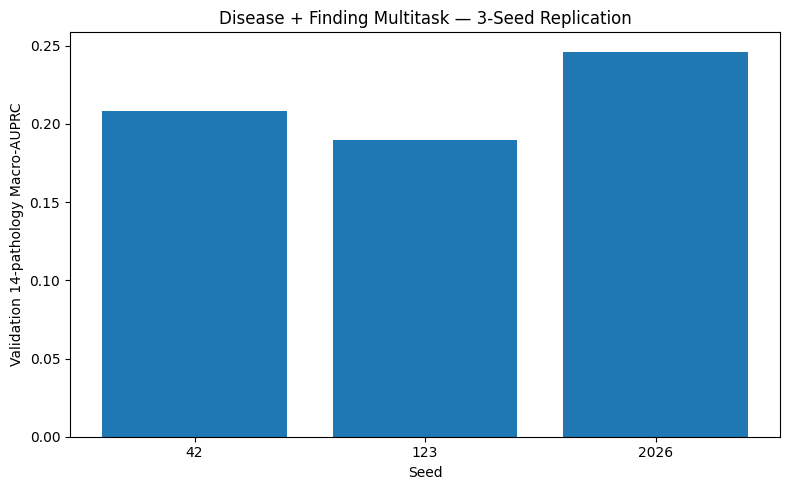

In [19]:
# ============================================================
# 20. Plot 3-seed variability
# ============================================================
fig, ax = plt.subplots(
    figsize=(
        8,
        5,
    )
)

ax.bar(
    three_seed[
        "seed"
    ].astype(
        str
    ),
    three_seed[
        "pathology14_macro_AUPRC"
    ],
)

ax.set_xlabel(
    "Seed"
)
ax.set_ylabel(
    "Validation 14-pathology Macro-AUPRC"
)
ax.set_title(
    "Disease + Finding Multitask — 3-Seed Replication"
)

plt.tight_layout()

plt.savefig(
    SUMMARY_DIR
    / "multitask_three_seed_macro_auprc.png",
    dpi=220,
    bbox_inches="tight",
)

plt.show()


In [20]:
# ============================================================
# 21. Final integrity checks
# ============================================================
new_configs = []

for seed in NEW_SEEDS:
    run_dir = (
        OUTPUT_ROOT
        / RUN_EXPERIMENT_IDS[
            seed
        ]
    )

    with open(
        run_dir
        / "config.json",
        "r",
    ) as f:
        new_configs.append(
            json.load(
                f
            )
        )

checks = pd.DataFrame([
    {
        "check":
            "Frozen Stage-02 SHA-256 verified",
        "passed":
            manifest_hash
            == EXPECTED_SPLIT_MANIFEST_SHA256,
    },
    {
        "check":
            "Train count = 5,408",
        "passed":
            len(
                train_df
            )
            == 5408,
    },
    {
        "check":
            "Validation count = 1,159",
        "passed":
            len(
                val_df
            )
            == 1159,
    },
    {
        "check":
            "Seed-42 09A reference checkpoint verified",
        "passed":
            reference_checkpoint.get(
                "experiment_id"
            )
            == REFERENCE_EXPERIMENT_ID,
    },
    {
        "check":
            "New seeds are exactly 123 and 2026",
        "passed":
            NEW_SEEDS
            == [
                123,
                2026,
            ],
    },
    {
        "check":
            "All three seed rows present",
        "passed":
            set(
                three_seed[
                    "seed"
                ].tolist()
            )
            == {
                42,
                123,
                2026,
            },
    },
    {
        "check":
            "All new runs use Focal gamma 2",
        "passed":
            all(
                np.isclose(
                    x[
                        "focal_gamma"
                    ],
                    2.0,
                )
                for x in new_configs
            ),
    },
    {
        "check":
            "All new runs use finding weight 0.5",
        "passed":
            all(
                np.isclose(
                    x[
                        "finding_loss_weight"
                    ],
                    0.5,
                )
                for x in new_configs
            ),
    },
    {
        "check":
            "All new runs use 320x320",
        "passed":
            all(
                x[
                    "image_size"
                ]
                == 320
                for x in new_configs
            ),
    },
    {
        "check":
            "No boxes used in new multitask runs",
        "passed":
            all(
                x[
                    "boxes_used"
                ]
                is False
                for x in new_configs
            ),
    },
    {
        "check":
            "Calibration unused",
        "passed":
            all(
                x[
                    "calibration_used"
                ]
                is False
                for x in new_configs
            ),
    },
    {
        "check":
            "Official test unused",
        "passed":
            all(
                x[
                    "official_test_used"
                ]
                is False
                for x in new_configs
            ),
    },
    {
        "check":
            "3-seed primary metrics finite",
        "passed":
            np.isfinite(
                three_seed[
                    "pathology14_macro_AUPRC"
                ].to_numpy(
                    dtype=float
                )
            ).all(),
    },
])

checks[
    "status"
] = checks[
    "passed"
].map({
    True:
        "PASS",
    False:
        "REVIEW",
})

checks.to_csv(
    SUMMARY_DIR
    / "final_integrity_status.csv",
    index=False,
)

display(
    checks
)

FINAL_STATUS = (
    "PASS"
    if checks[
        "passed"
    ].all()
    else "REVIEW"
)

print(
    "F01 MULTITASK 3-SEED FINAL STATUS:",
    FINAL_STATUS,
)

if (
    FINAL_STATUS
    != "PASS"
):
    raise RuntimeError(
        "Review integrity checks before localization replication."
    )


,check,passed,status
0,Frozen Stage-02 SHA-256 verified,True,PASS
1,"Train count = 5,408",True,PASS
2,"Validation count = 1,159",True,PASS
3,Seed-42 09A reference checkpoint verified,True,PASS
4,New seeds are exactly 123 and 2026,True,PASS
5,All three seed rows present,True,PASS
6,All new runs use Focal gamma 2,True,PASS
7,All new runs use finding weight 0.5,True,PASS
8,All new runs use 320x320,True,PASS
9,No boxes used in new multitask runs,True,PASS


F01 MULTITASK 3-SEED FINAL STATUS: PASS


In [21]:
# ============================================================
# 22. Human-readable final summary
# ============================================================
primary_row = (
    three_seed_summary.loc[
        three_seed_summary[
            "metric"
        ]
        == "pathology14_macro_AUPRC"
    ]
    .iloc[
        0
    ]
)

loc_head = (
    three_seed_summary.loc[
        three_seed_summary[
            "metric"
        ]
        == "head_macro_AUPRC"
    ]
    .iloc[
        0
    ]
)

loc_middle = (
    three_seed_summary.loc[
        three_seed_summary[
            "metric"
        ]
        == "middle_macro_AUPRC"
    ]
    .iloc[
        0
    ]
)

loc_tail = (
    three_seed_summary.loc[
        three_seed_summary[
            "metric"
        ]
        == "tail_macro_AUPRC"
    ]
    .iloc[
        0
    ]
)

readme = "\n".join([
    "F01 — Disease + Finding Multitask Final 3-Seed Replication",
    "=" * 76,
    "",
    "SEEDS",
    "- 42: existing frozen 09A reference",
    "- 123: exact 09A protocol replication",
    "- 2026: exact 09A protocol replication",
    "",
    "FROZEN PROTOCOL",
    "- ResNet50 @ 320x320",
    "- Disease Binary Focal Loss, gamma=2",
    "- Finding Binary Focal Loss, gamma=2",
    "- Finding-loss weight = 0.5",
    "- No boxes",
    "- Checkpoint selected by validation 14-pathology Macro-AUPRC",
    "",
    "3-SEED DISEASE RESULTS",
    (
        "- 14-pathology Macro-AUPRC: "
        f"{primary_row['mean']:.6f} ± {primary_row['std_sample']:.6f}"
    ),
    (
        "- Head Macro-AUPRC: "
        f"{loc_head['mean']:.6f} ± {loc_head['std_sample']:.6f}"
    ),
    (
        "- Middle Macro-AUPRC: "
        f"{loc_middle['mean']:.6f} ± {loc_middle['std_sample']:.6f}"
    ),
    (
        "- Tail Macro-AUPRC: "
        f"{loc_tail['mean']:.6f} ± {loc_tail['std_sample']:.6f}"
    ),
    "",
    "DATA SAFETY",
    "- Calibration used: NO",
    "- Official test used: NO",
    f"- Frozen split SHA-256: {manifest_hash}",
    "",
    "NEXT",
    "- Repeat the decoupled 10E localization adapter for seeds 123 and 2026 using these corresponding multitask checkpoints.",
])

print(
    readme
)

with open(
    SUMMARY_DIR
    / "README_RESULTS.txt",
    "w",
) as f:
    f.write(
        readme
    )


F01 — Disease + Finding Multitask Final 3-Seed Replication

SEEDS
- 42: existing frozen 09A reference
- 123: exact 09A protocol replication
- 2026: exact 09A protocol replication

FROZEN PROTOCOL
- ResNet50 @ 320x320
- Disease Binary Focal Loss, gamma=2
- Finding Binary Focal Loss, gamma=2
- Finding-loss weight = 0.5
- No boxes
- Checkpoint selected by validation 14-pathology Macro-AUPRC

3-SEED DISEASE RESULTS
- 14-pathology Macro-AUPRC: 0.214740 ± 0.028894
- Head Macro-AUPRC: 0.206075 ± 0.019923
- Middle Macro-AUPRC: 0.307723 ± 0.041598
- Tail Macro-AUPRC: 0.109341 ± 0.128489

DATA SAFETY
- Calibration used: NO
- Official test used: NO
- Frozen split SHA-256: 3d2f8de854c9f61382b1ef5594264af739fcb1d3d9ca8ca9fe8d388380363770

NEXT
- Repeat the decoupled 10E localization adapter for seeds 123 and 2026 using these corresponding multitask checkpoints.


In [22]:
# ============================================================
# 23. Package complete controller output
# ============================================================
ZIP_FILE = Path(
    "/kaggle/working/"
    "F01_Multitask_3Seed_Replication_All_Outputs.zip"
)

if (
    ZIP_FILE.exists()
):
    ZIP_FILE.unlink()

source_files = sorted(
    p
    for p in OUTPUT_ROOT.rglob(
        "*"
    )
    if p.is_file()
)

if (
    not source_files
):
    raise RuntimeError(
        "No controller output files found."
    )

for p in source_files:
    if (
        p.suffix.lower()
        in {
            ".dcm",
            ".dicom",
            ".npy",
            ".npz",
        }
    ):
        raise RuntimeError(
            "STOP: restricted/cache file detected in output folder: "
            + str(
                p
            )
        )

with zipfile.ZipFile(
    ZIP_FILE,
    mode="w",
    compression=
        zipfile.ZIP_DEFLATED,
    compresslevel=6,
) as zf:
    for p in source_files:
        zf.write(
            p,
            arcname=str(
                Path(
                    CONTROLLER_ID
                )
                / p.relative_to(
                    OUTPUT_ROOT
                )
            ),
        )

with zipfile.ZipFile(
    ZIP_FILE,
    "r",
) as zf:
    corrupt = (
        zf.testzip()
    )
    names = (
        zf.namelist()
    )

if (
    corrupt
    is not None
):
    raise RuntimeError(
        "ZIP integrity failure: "
        + str(
            corrupt
        )
    )

required_outputs = [
    "F01_Multitask_Seed123/best_model.pth",
    "F01_Multitask_Seed2026/best_model.pth",
    "summary/multitask_three_seed_results.csv",
    "summary/multitask_three_seed_mean_sd.csv",
    "summary/per_class_three_seed_mean_sd.csv",
    "summary/final_integrity_status.csv",
    "summary/README_RESULTS.txt",
]

missing_outputs = [
    x
    for x in required_outputs
    if (
        not any(
            name.endswith(
                x
            )
            for name in names
        )
    )
]

if (
    missing_outputs
):
    raise RuntimeError(
        "ZIP missing required outputs: "
        + str(
            missing_outputs
        )
    )

print(
    "✅ F01 COMPLETE OUTPUT ZIP CREATED"
)
print(
    "File:",
    ZIP_FILE,
)
print(
    "ZIP size:",
    f"{ZIP_FILE.stat().st_size/(1024**2):.2f} MB",
)
print(
    "ZIP integrity: PASS"
)
print(
    "DICOM/cache files included: NO"
)
print(
    "Official test used: NO"
)


✅ F01 COMPLETE OUTPUT ZIP CREATED
File: /kaggle/working/F01_Multitask_3Seed_Replication_All_Outputs.zip
ZIP size: 168.18 MB
ZIP integrity: PASS
DICOM/cache files included: NO
Official test used: NO


## What to send back

After the run finishes, send:

`F01_Multitask_3Seed_Replication_All_Outputs.zip`

I will verify:

- seeds 42 / 123 / 2026;
- mean ± SD of disease Macro-AUPRC;
- Head / Middle / Tail stability;
- finding-head stability;
- per-class seed variability;
- checkpoint/config integrity.

Then we will run the matching **10E localization-adapter replications for seeds 123 and 2026** before opening the official test set.
